# 01 — Análise Exploratória (EDA): freMTPL2

**Base:** French Motor Third-Party Liability (freMTPL2) — apólices de seguro auto de **responsabilidade civil (TPL)** na França.

**Fonte:** OpenML (ids 41214 freq / 41215 sev), espelho Kaggle `karansarpal/...`. Domínio público (CASdatasets).

**Estrutura:** uma tabela de *frequência* (1 linha/apólice, com exposição e nº de sinistros) e uma de *severidade* (1 linha/sinistro, com valor), unidas por `IDpol`.

Este notebook carrega o snapshot **processado** (`data/processed/`, gerado por `run_etl.py`) e explora os dados antes da modelagem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True

proc = None
for base in [pathlib.Path('.'), pathlib.Path('..')]:
    cand = base / 'data' / 'processed'
    if cand.exists():
        proc = cand
        break

def load(name):
    pq = proc / (name + '.parquet')
    cs = proc / (name + '.csv')
    return pd.read_parquet(pq) if pq.exists() else pd.read_csv(cs)

df = load('freMTPL2_modeling')
print('Apolices:', f'{len(df):,}', '| colunas:', df.shape[1])
df.head()

Apolices: 678,013 | colunas: 15


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount,Frequency,PurePremium
0,1,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82,0.0,10.000000,0.0
1,3,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82,0.0,1.298701,0.0
2,5,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22,0.0,1.333333,0.0
3,10,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72,0.0,11.111111,0.0
4,11,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72,0.0,1.190476,0.0


## 1. Visão geral e dicionário

Cada apólice traz a **exposição** (fração do ano coberta), o **nº de sinistros** (`ClaimNb`) e features de risco do condutor/veículo/região. `ClaimAmount` é o custo total de sinistros da apólice; `Frequency` e `PurePremium` já vêm derivados do ETL.

In [2]:
n = len(df)
com_sinistro = (df['ClaimNb'] > 0).mean()
freq_media = np.average(df['Frequency'], weights=df['Exposure'])
print(f'Apolices: {n:,}')
print(f'% com ao menos 1 sinistro: {com_sinistro:.2%}')
print(f'Frequencia media (ponderada por exposicao): {freq_media:.4f} sinistros/ano')
df[['Exposure', 'ClaimNb', 'ClaimAmount', 'PurePremium']].describe()

Apolices: 678,013
% com ao menos 1 sinistro: 5.02%
Frequencia media (ponderada por exposicao): 0.1006 sinistros/ano


,Exposure,ClaimNb,ClaimAmount,PurePremium
count,678013.000000,678013.000000,6.780130e+05,6.780130e+05
mean,0.528545,0.053179,8.835998e+01,3.832701e+02
std,0.364081,0.237954,5.822454e+03,3.682070e+04
min,0.002732,0.000000,0.000000e+00,0.000000e+00
25%,0.180000,0.000000,0.000000e+00,0.000000e+00
50%,0.490000,0.000000,0.000000e+00,0.000000e+00
75%,0.990000,0.000000,0.000000e+00,0.000000e+00
max,1.000000,4.000000,4.075401e+06,1.852455e+07


## 2. O alvo — frequência de sinistros

Sinistro é **evento raro**: a imensa maioria das apólices não tem nenhum. Isso justifica modelar a contagem com **Poisson** (e a exposição como offset).

Distribuicao de ClaimNb (proporcao):
ClaimNb
0    0.949765
1    0.047459
2    0.002631
3    0.000121
4    0.000024
Name: proportion, dtype: float64


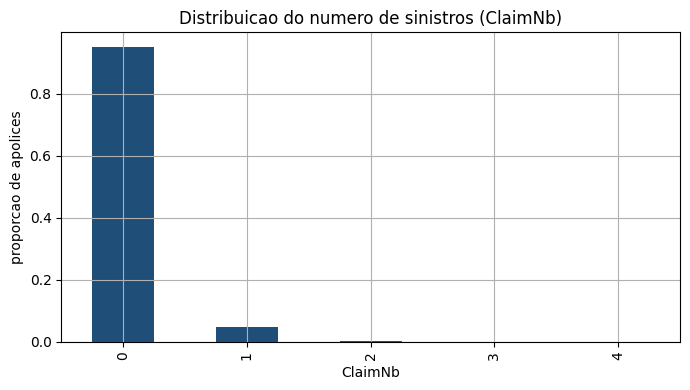

In [3]:
dist = df['ClaimNb'].value_counts(normalize=True).sort_index()
print('Distribuicao de ClaimNb (proporcao):')
print(dist)

ax = dist.plot(kind='bar', color='#1f4e79')
ax.set_title('Distribuicao do numero de sinistros (ClaimNb)')
ax.set_xlabel('ClaimNb')
ax.set_ylabel('proporcao de apolices')
plt.tight_layout()
plt.show()

## 3. Severidade — cauda pesada

Quando há sinistro, o custo é **fortemente assimétrico à direita** (poucos sinistros muito caros). Daí modelar a severidade com **Gamma** e o prêmio puro com **Tweedie**.

count    2.494400e+04
mean     2.222241e+03
std      2.899264e+04
min      1.000000e+00
25%      7.105550e+02
50%      1.172000e+03
75%      1.228080e+03
max      4.075401e+06
dtype: float64


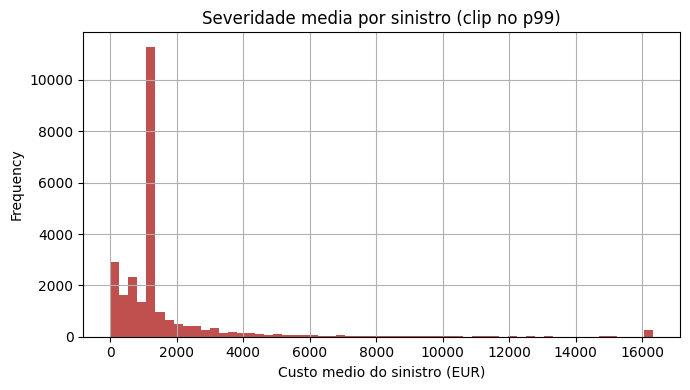

In [4]:
mask = (df['ClaimNb'] > 0) & (df['ClaimAmount'] > 0)
sev = df.loc[mask, 'ClaimAmount'] / df.loc[mask, 'ClaimNb']
print(sev.describe())

ax = sev.clip(upper=sev.quantile(0.99)).plot(kind='hist', bins=60, color='#c0504d')
ax.set_title('Severidade media por sinistro (clip no p99)')
ax.set_xlabel('Custo medio do sinistro (EUR)')
plt.tight_layout()
plt.show()

## 4. Drivers de risco

A frequência empírica por faixa revela os fatores que o modelo vai capturar. `BonusMalus` (histórico de sinistralidade) e idade são os mais fortes — coerência atuarial.

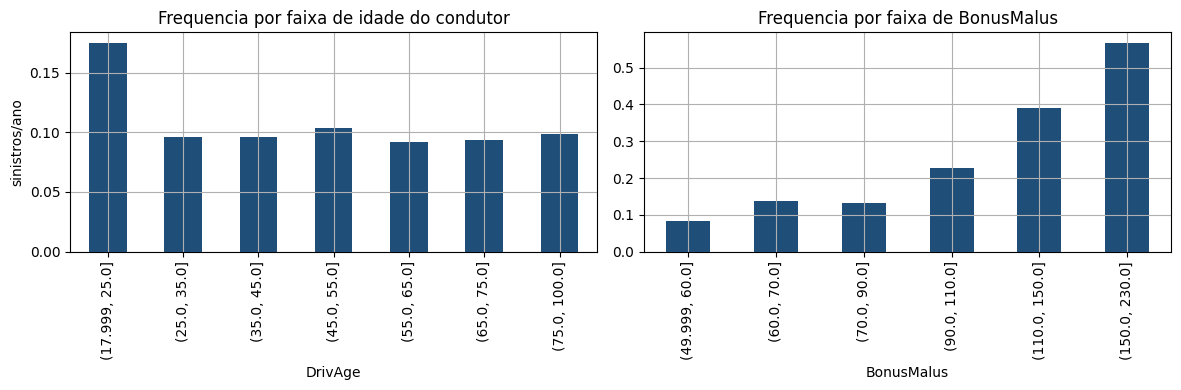

In [5]:
def freq_por_faixa(col, bins):
    faixa = pd.cut(df[col], bins=bins, include_lowest=True)
    return df.groupby(faixa, observed=True)[['ClaimNb', 'Exposure']].apply(
        lambda d: d['ClaimNb'].sum() / d['Exposure'].sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
freq_por_faixa('DrivAge', [18, 25, 35, 45, 55, 65, 75, 100]).plot(
    kind='bar', ax=axes[0], color='#1f4e79')
axes[0].set_title('Frequencia por faixa de idade do condutor')
axes[0].set_ylabel('sinistros/ano')

freq_por_faixa('BonusMalus', [50, 60, 70, 90, 110, 150, 230]).plot(
    kind='bar', ax=axes[1], color='#1f4e79')
axes[1].set_title('Frequencia por faixa de BonusMalus')
plt.tight_layout()
plt.show()

## 5. Conclusões (e ponte para a modelagem)

- **Frequência ~10%/ano**, evento raro → **Poisson** com offset de exposição.
- **Severidade de cauda pesada** → **Gamma**; prêmio puro → **Tweedie**.
- **BonusMalus e idade** são os drivers mais fortes — exatamente os que o **SHAP** destacou no GBM (`run_gbm_vs_glm.py`).
- Resultados dos modelos (GLM vs GBM + SHAP, calibração do prêmio puro) estão nos `run_*.py` e irão para `02_modeling.ipynb`.

→ Próximo: `02_modeling.ipynb` consolidando GLM freq/sev, prêmio puro e GLM vs GBM + SHAP, importando o `src/`.